In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from hmmlearn import hmm

np.random.seed(42)

# ---------------------------------------------------------
# 1. LOAD DATA
# ---------------------------------------------------------
df = pd.read_excel('master_dataset.xlsx', parse_dates=['Date'])
df = df.sort_values('Date').set_index('Date')
df = df.asfreq('B').ffill()

# ---------------------------------------------------------
# 2. FEATURE ENGINEERING
# ---------------------------------------------------------

# --- Market (NGX) ---
df['NGX_Return'] = np.log(df['ASI'] / df['ASI'].shift(1))
df['NGX_Vol']    = df['NGX_Return'].rolling(10).std()

# --- FX (USD/NGN) ---
df['FX_Return'] = np.log(df['USDNGN'] / df['USDNGN'].shift(1))
df['FX_Vol']    = df['FX_Return'].rolling(10).std()
df['FX_Trend']  = df['USDNGN'].rolling(30).mean()
df['FX_Trend_Raw'] = (df['USDNGN'] - df['FX_Trend']) / df['FX_Trend']

# --- FPI ---
df['FPI_Z'] = (df['Net FPI'] - df['Net FPI'].rolling(60).mean()) / df['Net FPI'].rolling(60).std()
df['FPI_Z'] = df['FPI_Z'].clip(-3, 3)

# --- Bond & Oil ---
df['Bond_Change']  = df['Bond_10Y'].diff()
df['Brent_Return'] = np.log(df['Brent_Crude'] / df['Brent_Crude'].shift(1))

# --- NGX Sharpe Z (risk-adjusted return signal, NOT momentum) ---
# Standard in regime-switching literature (see Ang & Timmermann 2012)
df['NGX_Sharpe_Z'] = df['NGX_Return'].rolling(20).mean() / \
    df['NGX_Return'].rolling(20).std()
df['NGX_Sharpe_Z'] = df['NGX_Sharpe_Z'].clip(-3, 3)

# --- Rolling Z-score ALL continuous features (single standardization pass) ---
# This replaces both the old StandardScaler AND the old raw features
for col in ['NGX_Return', 'NGX_Vol', 'FX_Return', 'FX_Vol', 'FX_Trend_Raw']:
    roll_mean = df[col].rolling(60).mean()
    roll_std  = df[col].rolling(60).std().replace(0, np.nan)
    df[f'{col}_Z'] = ((df[col] - roll_mean) / roll_std).clip(-3, 3)

df = df.dropna()

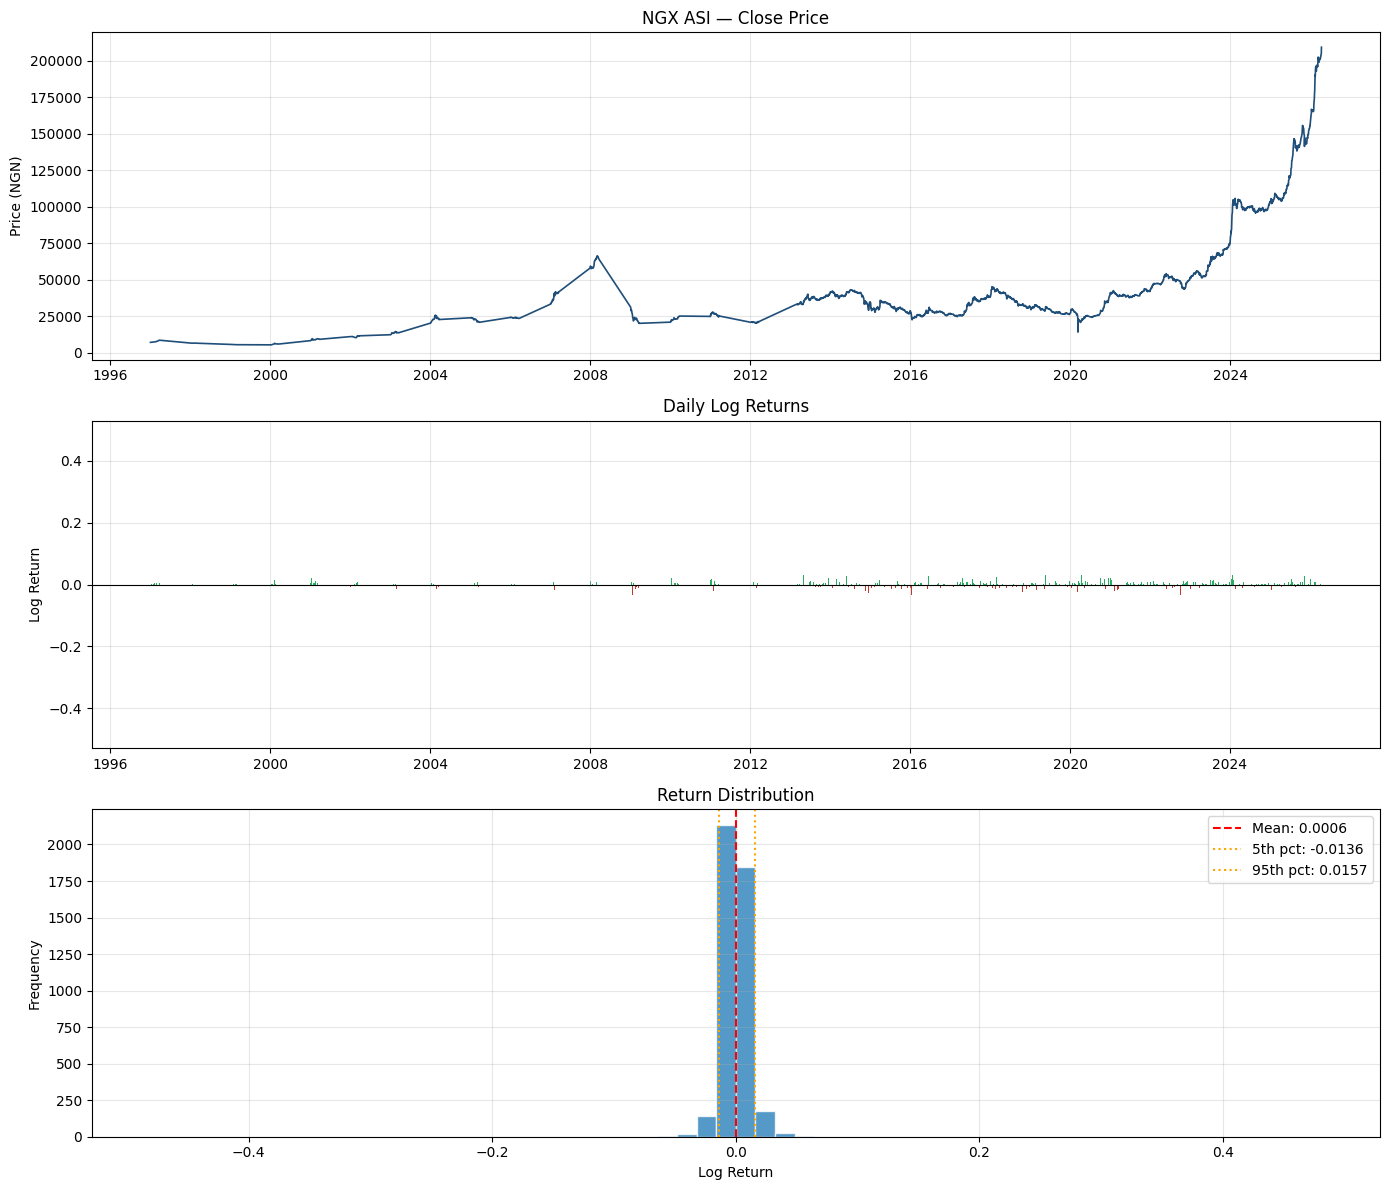

In [2]:
# Plot
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Price
axes[0].plot(df.index, df['ASI'], color='#1f4e79', linewidth=1.2)
axes[0].set_title('NGX ASI — Close Price')
axes[0].set_ylabel('Price (NGN)')
axes[0].grid(True, alpha=0.3)

# Daily returns
colors = ['#c0392b' if r < 0 else '#27ae60' for r in df['NGX_Return']]
axes[1].bar(df.index, df['NGX_Return'], color=colors, width=1)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Daily Log Returns')
axes[1].set_ylabel('Log Return')
axes[1].grid(True, alpha=0.3)

# Distribution
axes[2].hist(df['NGX_Return'], bins=60, color='#2980b9', edgecolor='white', alpha=0.8)
axes[2].axvline(df['NGX_Return'].mean(), color='red', linestyle='--',
                label=f"Mean: {df['NGX_Return'].mean():.4f}")
axes[2].axvline(df['NGX_Return'].quantile(0.05), color='orange', linestyle=':',
                label=f"5th pct: {df['NGX_Return'].quantile(0.05):.4f}")
axes[2].axvline(df['NGX_Return'].quantile(0.95), color='orange', linestyle=':',
                label=f"95th pct: {df['NGX_Return'].quantile(0.95):.4f}")
axes[2].set_title('Return Distribution')
axes[2].set_xlabel('Log Return')
axes[2].set_ylabel('Frequency')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('zenith_returns.png', dpi=150, bbox_inches='tight')
plt.show()

In [3]:
# ---------------------------------------------------------
# 4. PCA (MACRO: BRENT + BOND ONLY)
# ---------------------------------------------------------
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

macro_cols = ['Brent_Return', 'Bond_Change']

scaler_macro = StandardScaler()
df_macro  = scaler_macro.fit_transform(df[macro_cols])

pca = PCA(n_components=1)
df['Macro_Stress'] = pca.fit_transform(df_macro).flatten()


# Z-score Macro_Stress too so it lives on same scale as other features
for split_df, ref_df in [(df, df)]:
    mu  = ref_df['Macro_Stress'].mean()
    sig = ref_df['Macro_Stress'].std()
    split_df['Macro_Stress'] = ((split_df['Macro_Stress'] - mu) / sig).clip(-3, 3)

print("PCA Loadings:", pca.components_[0])


PCA Loadings: [-0.70710678  0.70710678]


In [4]:
# ---------------------------------------------------------
# 5. FINAL FEATURE SET
# ---------------------------------------------------------
features = [
    'NGX_Return_Z',
    'NGX_Sharpe_Z',
    'Macro_Stress',
    'FX_Return_Z',
]

# NO StandardScaler here — features are already on a common Z-score scale
# Applying scaler again on clipped data destroys the Gaussian assumption
X_full = df[features].values  # Using full dataset for Monte Carlo simulation

print("Feature means (should be near 0):")
print(df[features].mean().round(3))
print("Feature stds (should be near 1):")
print(df[features].std().round(3))

Feature means (should be near 0):
NGX_Return_Z    0.012
NGX_Sharpe_Z    0.085
Macro_Stress   -0.006
FX_Return_Z     0.014
dtype: float64
Feature stds (should be near 1):
NGX_Return_Z    1.010
NGX_Sharpe_Z    0.396
Macro_Stress    0.847
FX_Return_Z     0.880
dtype: float64


In [5]:
# ---------------------------------------------------------
# 6. HMM TRAINING WITH STICKY TRANSITION MATRIX
# ---------------------------------------------------------
model = hmm.GaussianHMM(
    n_components=3,
    covariance_type='full',
    n_iter=1000,
    random_state=42,
    params='stmc',      # s=startprob, t=transmat, m=means, c=covars
    init_params='stmc'
)


# model.init_params = 'mc'   # Don't reinitialize transmat — keep ours
# model.params = 'stmc'
# model.min_covar = 0.01     # Prevents covariance collapse which causes flickering

model.fit(X_full)  # Using full dataset for Monte Carlo simulation

,n_components,3
,covariance_type,'full'
,min_covar,0.001
,startprob_prior,1.0
,transmat_prior,1.0
,means_prior,0
,means_weight,0
,covars_prior,0.01
,covars_weight,1
,algorithm,'viterbi'
,random_state,42


In [6]:
df['State'] = model.predict(X_full)  # Using full dataset for Monte Carlo simulation

In [7]:
# ---------------------------------------------------------
# 8. ORDER STATES (INTERPRETABLE)
# ---------------------------------------------------------
state_means = df.groupby('State')['NGX_Return'].mean()
ordered_states = state_means.sort_values().index

mapping = {old: new for new, old in enumerate(ordered_states)}

df['State'] = df['State'].map(mapping)


In [8]:
print("\n--- TRAIN REGIMES ---")
print(df.groupby('State')[features].mean())


--- TRAIN REGIMES ---
       NGX_Return_Z  NGX_Sharpe_Z  Macro_Stress  FX_Return_Z
State                                                       
0         -0.163023     -0.214509      0.065716     0.066093
1         -0.004353     -0.041660     -0.016039    -0.024927
2          0.184092      0.489250     -0.058383     0.013817


In [9]:
state_returns = df.groupby('State')['NGX_Return'].mean().sort_values()
state_vols    = df.groupby('State')['NGX_Vol'].mean()

bear_state    = int(state_returns.index[0])   # Lowest return
bull_state    = int(state_returns.index[-1])  # Highest return
neutral_state = int(state_returns.index[1])   # Middle

color_map = {
    bear_state:    'red',
    bull_state:    'green',
    neutral_state: 'gold'
}

# Print state interpretation so we know what each state means
print("--- STATE INTERPRETATION ---")
for s in [bear_state, neutral_state, bull_state]:
    label = {bear_state: "BEAR", neutral_state: "TRANSITION", bull_state: "BULL"}[s]
    print(f"State {s} -> {label}")
    print(f"   Mean NGX_Return : {state_returns[s]:.6f}")
    print(f"   Mean NGX_Vol    : {state_vols[s]:.6f}")
    print()

--- STATE INTERPRETATION ---
State 0 -> BEAR
   Mean NGX_Return : -0.001696
   Mean NGX_Vol    : 0.008022

State 1 -> TRANSITION
   Mean NGX_Return : 0.000135
   Mean NGX_Vol    : 0.007707

State 2 -> BULL
   Mean NGX_Return : 0.003000
   Mean NGX_Vol    : 0.007608



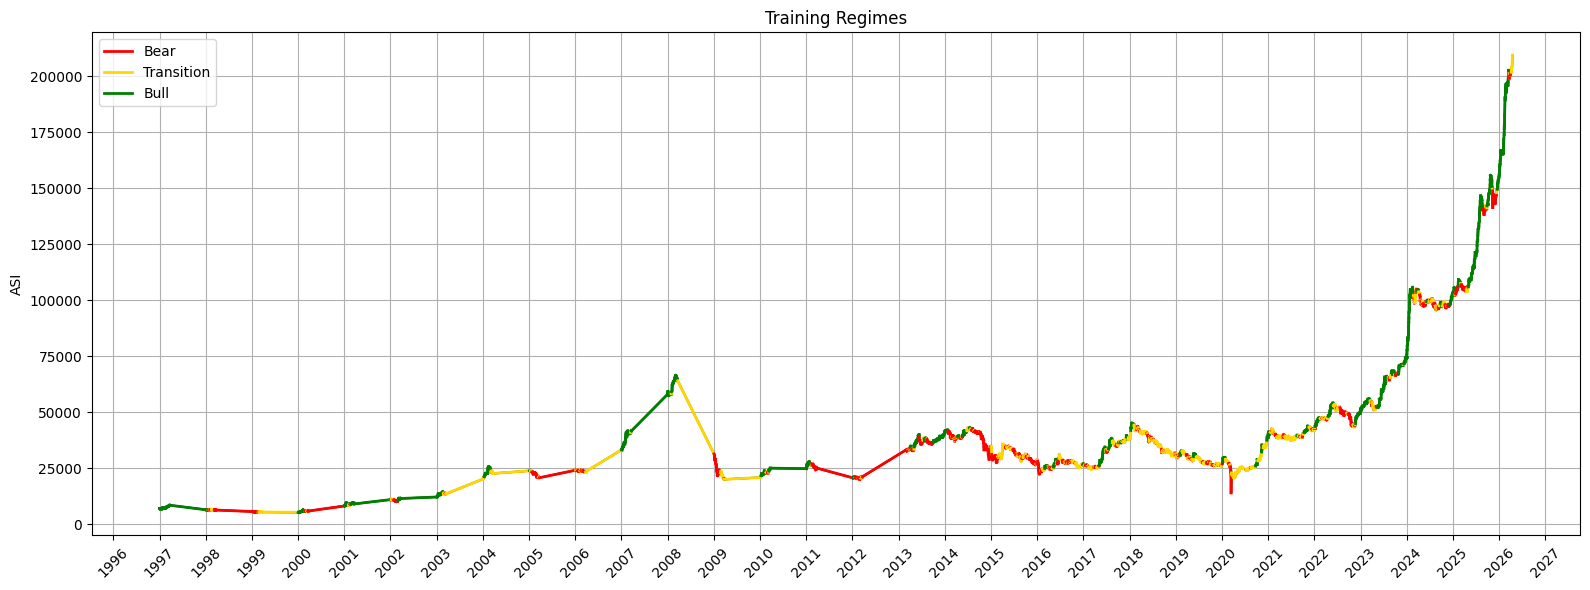

In [10]:
def plot_regimes(df, title):
    fig, ax = plt.subplots(figsize=(16,6))
    
    # FULL continuous ASI line
    ax.plot(df.index, df['ASI'], color='black', linewidth=1.5)
    
    # draw colored segments continuously
    for i in range(len(df)-1):
        state = df['State'].iloc[i]
        ax.plot(df.index[i:i+2],
                df['ASI'].iloc[i:i+2],
                color=color_map[state],
                linewidth=2)
    
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0],[0], color='red', lw=2, label='Bear'),
        Line2D([0],[0], color='gold', lw=2, label='Transition'),
        Line2D([0],[0], color='green', lw=2, label='Bull'),
    ]
    ax.legend(handles=legend_elements)
    ax.set_title(title)
    ax.set_ylabel("ASI")
    ax.grid(True)
    
    # Year-by-year x-axis
    import matplotlib.dates as mdates
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

plot_regimes(df, "Training Regimes")

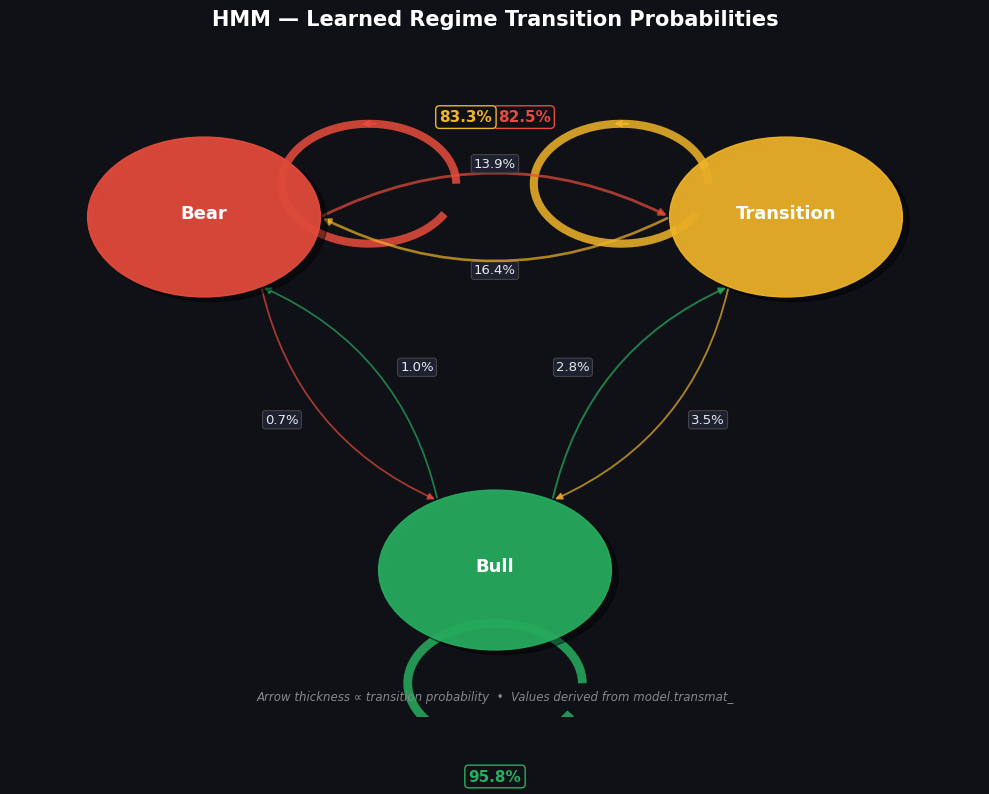

In [11]:
# ── Transition Matrix Visual ──────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# 1. Pull the LEARNED transition matrix directly from the fitted model
# This ensures we use the final probabilities after model.fit()
tm_raw = model.transmat_

# 2. Identify states based on LEARNED means to ensure correct labeling
# We sort by the first feature (NGX_Return_Z) so index 0=Bear, 1=Transition, 2=Bull
# model.means_ shape is (n_components, n_features)
learned_return_means = model.means_[:, 0]
ordered_indices = np.argsort(learned_return_means)

# 3. Re-map the transition matrix to match the [Bear, Transition, Bull] order
tm = tm_raw[np.ix_(ordered_indices, ordered_indices)]

# Visualization configuration
labels      = ["Bear", "Transition", "Bull"]
colors      = ["#e74c3c", "#f0b429", "#27ae60"]
node_radius = 0.12

fig, ax = plt.subplots(figsize=(10, 8))
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
fig.patch.set_facecolor("#0f1117")
ax.set_facecolor("#0f1117")

# Node positions (triangle layout)
# index 0: Bear (Top Left), index 1: Transition (Top Right), index 2: Bull (Bottom Center)
positions = [(0.20, 0.75), (0.80, 0.75), (0.50, 0.22)]

# ── Draw edges (Transitions) ──────────────────────────────────────────────────
for i in range(3):
    for j in range(3):
        prob = tm[i, j]
        if prob < 0.001:
            continue

        x0, y0 = positions[i]
        x1, y1 = positions[j]

        if i == j:
            # Self-loop arc
            cx, cy = x0 + (0.17 if i == 0 else -0.17 if i == 1 else 0), \
                     y0 + (0.05 if i != 2 else -0.17)
            loop   = mpatches.Arc(
                (cx, cy), 0.18, 0.18,
                angle=0, theta1=0, theta2=330,
                color=colors[i], lw=2.5 + prob * 4, alpha=0.85
            )
            ax.add_patch(loop)
            # Arrowhead on loop
            ax.annotate("", xy=(cx - 0.01, cy + 0.09),
                        xytext=(cx + 0.01, cy + 0.09),
                        arrowprops=dict(arrowstyle="->", color=colors[i], lw=1.5))
            # Probability label
            lx = cx + (0.16 if i == 0 else -0.16 if i == 1 else 0)
            ly = cy + (0.10 if i != 2 else -0.14)
            ax.text(lx, ly, f"{prob:.1%}", ha="center", va="center",
                    fontsize=11, fontweight="bold", color=colors[i],
                    bbox=dict(boxstyle="round,pad=0.25", fc="#0f1117", ec=colors[i], lw=1))
        else:
            # Curved arrow between nodes
            dx, dy  = x1 - x0, y1 - y0
            dist    = np.hypot(dx, dy)
            ux, uy  = dx / dist, dy / dist
            perp    = np.array([-uy, ux]) * 0.08 * (1 if (i + j) % 2 == 0 else -1)

            sx, sy = x0 + ux * node_radius, y0 + uy * node_radius
            ex, ey = x1 - ux * node_radius, y1 - uy * node_radius

            mid = np.array([(sx + ex) / 2, (sy + ey) / 2]) + perp
            ax.annotate(
                "", xy=(ex, ey), xytext=(sx, sy),
                arrowprops=dict(
                    arrowstyle="-|>",
                    color=colors[i],
                    lw=1.2 + prob * 5,
                    connectionstyle=f"arc3,rad={0.25 * (1 if (i+j)%2==0 else -1)}",
                    alpha=0.7
                )
            )
            # Probability label along edge midpoint
            lx, ly = mid
            ax.text(lx, ly, f"{prob:.1%}", ha="center", va="center",
                    fontsize=9.5, color="white", alpha=0.9,
                    bbox=dict(boxstyle="round,pad=0.2", fc="#1e2130", ec="#444", lw=0.8))

# ── Draw nodes (Regimes) ──────────────────────────────────────────────────────
for idx, (x, y) in enumerate(positions):
    circle = plt.Circle((x, y), node_radius, color=colors[idx], zorder=5, alpha=0.92)
    shadow = plt.Circle((x + 0.007, y - 0.007), node_radius, color="black", zorder=4, alpha=0.4)
    ax.add_patch(shadow)
    ax.add_patch(circle)
    ax.text(x, y + 0.005, labels[idx], ha="center", va="center",
            fontsize=13, fontweight="bold", color="white", zorder=6)

# ── Title & Note ──────────────────────────────────────────────────────────────
ax.set_title("HMM — Learned Regime Transition Probabilities",
             color="white", fontsize=15, fontweight="bold", pad=18)
ax.text(0.5, 0.02,
        "Arrow thickness ∝ transition probability  •  Values derived from model.transmat_",
        ha="center", va="bottom", transform=ax.transAxes,
        fontsize=8.5, color="#888", style="italic")

plt.tight_layout()
plt.show()